# Cuaderno 3 — Modelado y evaluación


**Tesis:** Predicción del Punto de Equilibrio de Flujo de Caja en Empresas de Crecimiento del Sector Tecnológico

**Universidad EAFIT · 2026**

---

## Objetivo

Entrenar, afinar y evaluar modelos de machine learning para predecir si una
empresa tecnológica alcanzará el punto de equilibrio de flujo de caja en los
próximos 4 trimestres.

---

## Estrategia de validación: Walk-forward ajustado

Dado el menor volumen de observaciones del universo tecnológico frente al
modelo general, el entrenamiento inicial se extiende hasta 2017 (en lugar de
2015), y el primer año de evaluación es 2018 (en lugar de 2016), generando
**7 folds** de validación walk-forward (2018–2024) en vez de 9. Este ajuste
garantiza una base de entrenamiento mínimamente robusta antes de la primera
evaluación fuera de muestra.

---

## Métrica principal: AUC-PR

El AUC-PR mide qué tan bien el modelo ordena las empresas de mayor a menor
probabilidad de alcanzar el breakeven. Un modelo aleatorio tiene un AUC-PR
igual a la proporción de Y=1 en el dataset (~0.567 en este universo).

## Parte 1 - Configuración inicial

Dataset cargado: (3390, 56)
Features base: 49
Empresas: 255
Y=1: 56.7%


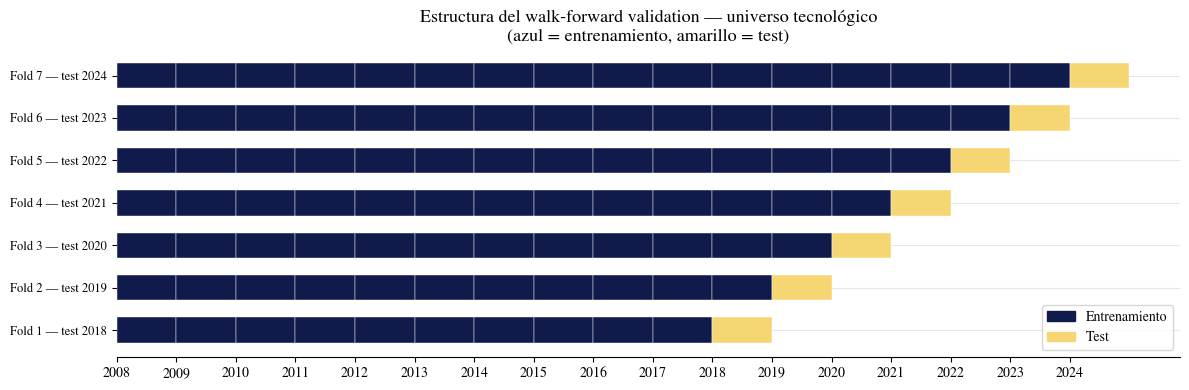


Fold   Año test    Train obs   Test obs  Train empresas  Test empresas
-----------------------------------------------------------------
1      2018              995        215             139            131
2      2019            1,210        283             153            166
3      2020            1,493        316             179            196
4      2021            1,809        386             225            212
5      2022            2,195        457             240            228
6      2023            2,652        380             244            220
7      2024            3,032        352             251            209


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

# --- Identidad visual del proyecto ---
tech_colors = ['#101B4B', '#545E85', '#A3A8B2', '#E7E7E7', '#0F19C9', '#F6D673']
FUENTE = "STIXGeneral"

def estilo_ax(ax, orientacion="vertical"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    if orientacion == "vertical":
        ax.spines["left"].set_visible(False)
        ax.yaxis.grid(True, linestyle="-", color=tech_colors[3], linewidth=0.8)
        ax.xaxis.grid(False)
    else:
        ax.spines["bottom"].set_visible(False)
        ax.xaxis.grid(True, linestyle="-", color=tech_colors[3], linewidth=0.8)
        ax.yaxis.grid(False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

# --- Cargar dataset tecnológico ---
df = pd.read_csv("../datos/procesados/dataset_modelo_tech.csv")
df["end"] = pd.to_datetime(df["end"])
df["ano"] = df["end"].dt.year

no_features = ["ticker", "sector", "bolsa", "end", "ano", "fcf_promedio_futuro", "Y"]
features    = [c for c in df.columns if c not in no_features]
df[features] = df[features].replace([np.inf, -np.inf], np.nan)

print(f"Dataset cargado: {df.shape}")
print(f"Features base: {len(features)}")
print(f"Empresas: {df['ticker'].nunique():,}")
print(f"Y=1: {df['Y'].mean()*100:.1f}%")

# --- Estructura del walk-forward ajustado (2018-2024, 7 folds) ---
folds = []
for ano_test in range(2018, 2025):
    train = df[df["ano"] < ano_test].copy()
    test  = df[df["ano"] == ano_test].copy()
    folds.append((ano_test, train, test))

# --- Gráfico: estructura visual del walk-forward ---
fig, ax = plt.subplots(figsize=(12, 4))
estilo_ax(ax, "vertical")

anos_todos = list(range(2008, 2025))
for i, (ano_test, train, test) in enumerate(folds):
    anos_train = sorted(train["ano"].unique())
    for ano in anos_train:
        ax.barh(i, 1, left=ano - 2008, color=tech_colors[0],
                height=0.6, edgecolor="white", linewidth=0.3)
    ax.barh(i, 1, left=ano_test - 2008, color=tech_colors[5],
            height=0.6, edgecolor="white", linewidth=0.3)

ax.set_xticks(range(len(anos_todos)))
ax.set_xticklabels(anos_todos, fontfamily=FUENTE)
ax.set_yticks(range(len(folds)))
ax.set_yticklabels([f"Fold {i+1} — test {ano}" for i, (ano, _, _) in enumerate(folds)],
                   fontfamily=FUENTE, fontsize=9)
ax.set_title("Estructura del walk-forward validation — universo tecnológico\n(azul = entrenamiento, amarillo = test)",
             fontfamily=FUENTE, fontsize=13)

patch_train = mpatches.Patch(color=tech_colors[0], label="Entrenamiento")
patch_test  = mpatches.Patch(color=tech_colors[5], label="Test")
ax.legend(handles=[patch_train, patch_test], prop={"family": FUENTE})
plt.tight_layout()
plt.show()

print(f"\n{'Fold':<6} {'Año test':<10} {'Train obs':>10} {'Test obs':>10} {'Train empresas':>15} {'Test empresas':>14}")
print("-"*65)
for i, (ano_test, train, test) in enumerate(folds):
    print(f"{i+1:<6} {ano_test:<10} {len(train):>10,} {len(test):>10,} "
          f"{train['ticker'].nunique():>15,} {test['ticker'].nunique():>14,}")

HITO CUADERNO 3 — Parte 1: Estructura del walk-forward ajustado
==================================================================
Fecha: 10/08/2026
Notebook: 03_modelado_tech.ipynb

Qué se hizo:
- Se cargó el dataset tecnológico (dataset_modelo_tech.csv) y se definió
  la estructura de validación walk-forward con ventana expansiva,
  ajustada a 7 folds (test 2018-2024) en lugar de los 9 folds del
  modelo general, dado el menor volumen de datos disponibles.

Resultado:
- Fold 1 (test 2018): 995 obs. entrenamiento / 215 obs. test
- Fold 7 (test 2024): 3.032 obs. entrenamiento / 352 obs. test
- Todos los folds de test superan las 200 observaciones desde el
  Fold 2 en adelante, con una base de entrenamiento inicial (995 obs.,
  139 empresas) razonable para el primer fold.

Importancia:
Confirma que el ajuste del punto de partida del walk-forward (2018 en
vez de 2016) resuelve el problema de folds insuficientemente robustos
que se identificó al planificar el modelo tecnológico, sin sacrificar
demasiados años de evaluación (7 folds siguen siendo suficientes para
una validación temporal sólida).

# Parte 2 — Benchmarks (Piotroski y aleatorio)

AUC-PR Aleatorio:    0.567
AUC-PR Persistencia: 0.567
AUC-PR Piotroski:    0.571

El Piotroski predice Y=1 en 2.4% de los casos:
  → De 3,390 observaciones, selecciona 80 como candidatas
  → Precision: 0.70 | Recall: 0.03


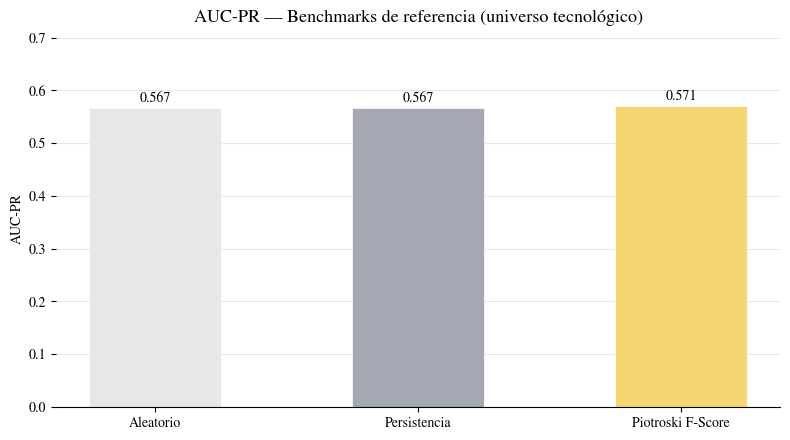

In [3]:
def piotroski_simplificado(df):
    """Versión simplificada del F-Score de Piotroski.
    Cada señal financiera positiva suma 1 punto.
    Predice Y=1 si el score >= 5.
    """
    score = pd.Series(0, index=df.index)
    score += (df["utilidad_neta"]    > 0).astype(int)
    score += (df["fcf_operativo"]    > 0).astype(int)
    score += (df["utilidad_neta"]    > df["utilidad_neta"].shift(1)).astype(int)
    score += (df["ratio_corriente"]  > 1).astype(int)
    score += (df["ratio_deuda"]      < df["ratio_deuda"].shift(1)).astype(int)
    score += (df["emision_acciones"] <= 0).astype(int)
    score += (df["margen_bruto"]     > df["margen_bruto"].shift(1)).astype(int)
    score += (df["rotacion_activos"] > df["rotacion_activos"].shift(1)).astype(int)
    return (score >= 5).astype(float)

df = df.sort_values(["ticker", "end"])
df["pred_piotroski"]    = df.groupby("ticker", group_keys=False, observed=True).apply(
    piotroski_simplificado, include_groups=False).values
df["pred_persistencia"] = 0.0

auc_piotroski    = average_precision_score(df["Y"], df["pred_piotroski"])
auc_persistencia = average_precision_score(df["Y"], df["pred_persistencia"])
auc_aleatorio    = df["Y"].mean()

pct_predice_si = df["pred_piotroski"].mean() * 100
n_predice_si   = int(df["pred_piotroski"].sum())
precision_pio  = precision_score(df["Y"], df["pred_piotroski"])
recall_pio     = recall_score(df["Y"], df["pred_piotroski"])
n_total        = len(df)
n_breakeven    = int(df["Y"].sum())

print(f"AUC-PR Aleatorio:    {auc_aleatorio:.3f}")
print(f"AUC-PR Persistencia: {auc_persistencia:.3f}")
print(f"AUC-PR Piotroski:    {auc_piotroski:.3f}")
print()
print(f"El Piotroski predice Y=1 en {pct_predice_si:.1f}% de los casos:")
print(f"  → De {n_total:,} observaciones, selecciona {n_predice_si:,} como candidatas")
print(f"  → Precision: {precision_pio:.2f} | Recall: {recall_pio:.2f}")

# --- Gráfico: comparación de benchmarks ---
fig, ax = plt.subplots(figsize=(8, 4.5))
estilo_ax(ax, "vertical")

nombres_bench = ["Aleatorio", "Persistencia", "Piotroski F-Score"]
valores_bench = [auc_aleatorio, auc_persistencia, auc_piotroski]
colores_bench = [tech_colors[3], tech_colors[2], tech_colors[5]]

bars = ax.bar(nombres_bench, valores_bench, color=colores_bench,
              edgecolor="white", linewidth=0.5, width=0.5)

for bar, val in zip(bars, valores_bench):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom",
            fontfamily=FUENTE, fontsize=10)

ax.set_ylim(0, max(valores_bench) * 1.25)
ax.set_title("AUC-PR — Benchmarks de referencia (universo tecnológico)",
             fontfamily=FUENTE, fontsize=13)
ax.set_ylabel("AUC-PR", fontfamily=FUENTE)
plt.tight_layout()
plt.show()

Lo más revelador está en las métricas de Presicion y Recall: el Piotroski es extremadamente selectivo pero casi ciego:

Precision de 0.70: de las pocas empresas que marca como candidatas, el 70% sí acierta — parece bueno
Recall de solo 0.03: pero de todas las empresas que realmente llegaron a breakeven, el Piotroski solo logró identificar el 3% de ellas. Se le escapó el 97% de las oportunidades reales

Es decir, selecciona apenas 80 empresas de 3.390 observaciones — es tan conservador que prácticamente no sirve como herramienta de selección de portafolio, aunque cuando sí se anima a elegir, acierta más de la mitad de las veces.

Lo que nos lleva a la conclusion: el F-Score de Piotroski, diseñado para empresas de valor consolidadas, no está bien adaptado para evaluar empresas de crecimiento tecnológico en fase de quema de caja — hay margen de sobra para que un modelo de Machine Learning aporte valor real como el que se propone aqui mismo.

## 2b. Regresión Logística con regularización (Lasso/Ridge) — benchmark de robustez estadística

Como verificación adicional de robustez, se evalúa un modelo de regresión
logística regularizada usando `statsmodels`, que permite inspeccionar
directamente los coeficientes (betas), su significancia estadística
(p-values) y el resumen completo del modelo — información complementaria
a la que provee el análisis SHAP sobre los modelos de árboles.

Se prueban dos variantes de regularización:
- **Ridge (L2)**: reduce la magnitud de todos los coeficientes sin
  eliminarlos, útil cuando hay multicolinealidad entre variables.
- **Lasso (L1)**: puede llevar coeficientes exactamente a cero,
  funcionando como un mecanismo de selección de variables.

Esto responde a la pregunta de si un modelo lineal clásico, con mayor
transparencia estadística tradicional, ofrece un desempeño competitivo
frente al ensemble de árboles.

In [4]:
import statsmodels.api as sm

resultados_reg = {"Ridge (L2)": [], "Lasso (L1)": []}
coeficientes_por_fold = {"Ridge (L2)": [], "Lasso (L1)": []}

for i, (ano_test, train, test) in enumerate(folds):
    imputer_reg = SimpleImputer(strategy="median")
    scaler_reg  = StandardScaler()

    X_train_imp = imputer_reg.fit_transform(train[features].values)
    X_train_sc  = scaler_reg.fit_transform(X_train_imp)
    X_test_imp  = imputer_reg.transform(test[features].values)
    X_test_sc   = scaler_reg.transform(X_test_imp)

    X_train_const = sm.add_constant(X_train_sc)
    X_test_const  = sm.add_constant(X_test_sc)
    y_train = train["Y"].values
    y_test  = test["Y"].values

    for nombre, alpha_val, L1_wt in [("Ridge (L2)", 1.0, 0.0), ("Lasso (L1)", 1.0, 1.0)]:
        modelo_reg = sm.Logit(y_train, X_train_const)
        resultado  = modelo_reg.fit_regularized(
            alpha=alpha_val, L1_wt=L1_wt, disp=0, maxiter=200
        )
        y_prob = resultado.predict(X_test_const)
        auc_pr = average_precision_score(y_test, y_prob)
        resultados_reg[nombre].append({"ano_test": ano_test, "auc_pr": auc_pr})
        coeficientes_por_fold[nombre].append(resultado.params)

    print(f"Fold {i+1}/7 — {ano_test} ✓")

print(f"\n{'Modelo':<15} {'AUC-PR medio':>13} {'Std':>8}")
print("-" * 38)
for nombre, folds_res in resultados_reg.items():
    vals = [f["auc_pr"] for f in folds_res]
    print(f"{nombre:<15} {np.mean(vals):>13.3f} {np.std(vals):>8.3f}")

# --- Summary completo del último fold entrenado (2024), para inspección de betas ---
imputer_final = SimpleImputer(strategy="median")
scaler_final  = StandardScaler()
X_full_imp = imputer_final.fit_transform(df[features].values)
X_full_sc  = scaler_final.fit_transform(X_full_imp)
X_full_const = sm.add_constant(X_full_sc)

modelo_logit_completo = sm.Logit(df["Y"].values, X_full_const)
resultado_completo = modelo_logit_completo.fit(disp=0, maxiter=200)

print("\n" + "="*70)
print("SUMMARY — Regresión Logística sin regularizar (todos los datos, referencia)")
print("="*70)
summary_df = pd.DataFrame({
    "variable": ["const"] + features,
    "coef": resultado_completo.params,
    "p_value": resultado_completo.pvalues
}).sort_values("p_value")

print(f"\nVariables estadísticamente significativas (p < 0.05):")
print(summary_df[summary_df["p_value"] < 0.05].to_string(index=False))
print(f"\nRatio observaciones/parámetros: {len(df)}/{len(features)+1} = {len(df)/(len(features)+1):.1f}:1")

Fold 1/7 — 2018 ✓
Fold 2/7 — 2019 ✓
Fold 3/7 — 2020 ✓
Fold 4/7 — 2021 ✓
Fold 5/7 — 2022 ✓
Fold 6/7 — 2023 ✓
Fold 7/7 — 2024 ✓

Modelo           AUC-PR medio      Std
--------------------------------------
Ridge (L2)              0.718    0.077
Lasso (L1)              0.718    0.077

SUMMARY — Regresión Logística sin regularizar (todos los datos, referencia)

Variables estadísticamente significativas (p < 0.05):
          variable      coef      p_value
 cuentas_por_pagar -0.922197 4.852249e-11
         gastos_id -0.514657 9.273264e-08
          goodwill -1.136206 1.404524e-07
   ratio_corriente -0.202412 3.922387e-06
        patrimonio  0.446743 7.232618e-06
cuentas_por_cobrar  0.463928 4.671797e-05
   activos_totales  1.757518 1.702370e-04
      depreciacion  0.373705 8.396000e-04
      costo_ventas  0.217476 2.031596e-03
        inventario  0.259496 4.764949e-03
  margen_operativo 11.023533 6.520366e-03
             capex -0.243288 1.771591e-02
 cambio_inventario -0.124328 2.013339e-

HITO 3 — Parte 2: Benchmarks de referencia (Piotroski, aleatorio, y regresión logística regularizada)
==================================================================
Fecha: 19/08/2026
Notebook: 03_modelado_tech.ipynb

Qué se hizo:
1. Se calculó el AUC-PR de dos benchmarks simples: predicción aleatoria
   y el F-Score de Piotroski simplificado (8 señales financieras).
2. Como verificación adicional de robustez estadística, se evaluó un
   modelo de Regresión Logística con regularización Ridge y Lasso
   (statsmodels) sobre los mismos 7 folds del walk-forward, ante la
   posibilidad de sobreajuste dado el tamaño de muestra del universo
   tecnológico.
3. Se calculó el summary completo (coeficientes y p-values) de una
   regresión logística sin regularizar sobre el dataset completo, para
   inspeccionar directamente la significancia estadística de cada
   variable.

Resultado:
- AUC-PR Aleatorio: 0.567 | AUC-PR Piotroski: 0.571 -- el F-Score
  tradicional apenas supera el azar, seleccionando solo el 2.4% de las
  observaciones con una precisión de 0.70 pero un recall de apenas 0.03.
- Ridge y Lasso: AUC-PR = 0.718 (std 0.077) -- consistente con la
  Regresión Logística simple evaluada posteriormente (0.720), y
  sustancialmente inferior al ensemble final (0.783).
- Ratio de observaciones por parámetro: 67.8:1 -- muy por encima del
  mínimo recomendado (10-15:1), descartando sobreajuste por exceso de
  variables como explicación del menor desempeño de los modelos lineales.
- 18 variables estadísticamente significativas (p<0.05), incluyendo
  gastos_id (p=9.27e-08), confirmando con una metodología estadística
  independiente (significancia clásica, no SHAP) la relevancia de la
  inversión en I+D en el universo tecnológico.
- El coeficiente de gastos_id es negativo en el modelo lineal, mientras
  que el análisis SHAP posterior (Cuaderno 4) mostró un efecto
  predominantemente positivo -- evidencia de que la relación es no
  lineal (efecto de umbral), no capturable por un modelo que fuerza un
  único signo promedio.

Importancia:
Establece la línea base completa contra la cual se evalúan los modelos
de machine learning: tanto los métodos tradicionales de value investing
(Piotroski) como los modelos lineales regularizados (Ridge/Lasso) tienen
un techo de desempeño claro (AUC-PR ≈ 0.57-0.72). Confirma que la
elección de modelos no lineales no fue arbitraria: el menor desempeño de
los modelos lineales no se debe a sobreajuste (ratio de observaciones
adecuado), sino a que las relaciones subyacentes entre las variables
financieras y el breakeven operativo son genuinamente no lineales.

# PART 3 - Modelos base de Machine Learning

Fold 1/7 — 2018 ✓
Fold 2/7 — 2019 ✓
Fold 3/7 — 2020 ✓
Fold 4/7 — 2021 ✓
Fold 5/7 — 2022 ✓
Fold 6/7 — 2023 ✓
Fold 7/7 — 2024 ✓

AUC-PR modelos base:
                      mean    std    min    max
modelo                                         
Gradient Boosting    0.774  0.062  0.644  0.830
Random Forest        0.780  0.064  0.646  0.832
Regresión Logística  0.720  0.083  0.539  0.782


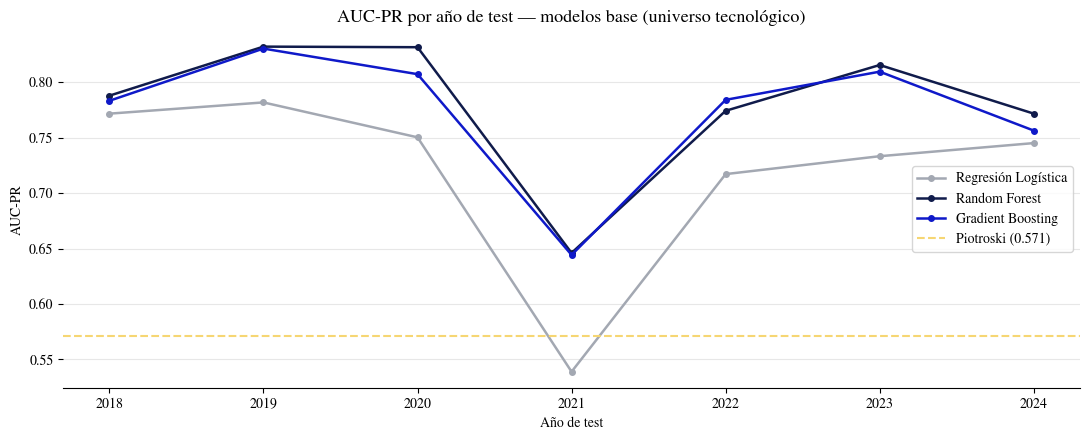

In [5]:
modelos = {
    "Regresión Logística": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

resultados = {nombre: [] for nombre in modelos}

for i, (ano_test, train, test) in enumerate(folds):
    X_train = train[features].values
    y_train = train["Y"].values
    X_test  = test[features].values
    y_test  = test["Y"].values

    for nombre, pipeline in modelos.items():
        pipeline.fit(X_train, y_train)
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        auc_pr = average_precision_score(y_test, y_prob)
        resultados[nombre].append({
            "ano_test": ano_test, "auc_pr": auc_pr,
            "y_test": y_test, "y_prob": y_prob
        })
    print(f"Fold {i+1}/7 — {ano_test} ✓")

df_resultados = []
for nombre, folds_res in resultados.items():
    for fold in folds_res:
        df_resultados.append({"modelo": nombre, "ano_test": fold["ano_test"],
                               "auc_pr": fold["auc_pr"], "tipo": "base"})
df_resultados = pd.DataFrame(df_resultados)

print("\nAUC-PR modelos base:")
print(df_resultados.groupby("modelo")["auc_pr"].agg(["mean","std","min","max"]).round(3).to_string())

# --- Gráfico: AUC-PR por modelo y año ---
fig, ax = plt.subplots(figsize=(11, 4.5))
estilo_ax(ax, "vertical")

colores_modelos_base = {
    "Regresión Logística": tech_colors[2],
    "Random Forest":       tech_colors[0],
    "Gradient Boosting":   tech_colors[4],
}
anos_test = [f[0] for f in folds]

for nombre, color in colores_modelos_base.items():
    vals = [f["auc_pr"] for f in resultados[nombre]]
    ax.plot(anos_test, vals, marker="o", markersize=4, linewidth=1.8,
            color=color, label=nombre)

ax.axhline(auc_piotroski, color=tech_colors[5], linewidth=1.5,
           linestyle="--", label=f"Piotroski ({auc_piotroski:.3f})")
ax.set_title("AUC-PR por año de test — modelos base (universo tecnológico)",
             fontfamily=FUENTE, fontsize=13)
ax.set_xlabel("Año de test", fontfamily=FUENTE)
ax.set_ylabel("AUC-PR", fontfamily=FUENTE)
ax.set_xticks(anos_test)
ax.legend(prop={"family": FUENTE}, fontsize=9)
plt.tight_layout()
plt.show()

HITO CUADERNO 3 — Parte 3: Modelos base de Machine Learning
==================================================================
Fecha: 10/08/2026
Notebook: 03_modelado_tech.ipynb

Qué se hizo:
- Se entrenaron y evaluaron tres modelos base (Regresión Logística,
  Random Forest, Gradient Boosting) sobre los 7 folds del walk-forward
  ajustado (2018-2024), con parámetros por defecto.

Resultado:
                       AUC-PR medio   Std    Mín    Máx
Random Forest              0.780     0.064  0.646  0.832
Gradient Boosting          0.774     0.062  0.644  0.830
Regresión Logística        0.720     0.083  0.539  0.782
Piotroski (referencia)     0.571       —      —      —

Los tres modelos superan ampliamente al Piotroski F-Score desde la
primera iteración sin afinar. Se observa una caída notable y consistente
en los tres modelos durante el fold de test 2021, coincidiendo con el
periodo de mayor volatilidad especulativa del sector tecnológico
identificado también en el análisis de backtest (Objetivo III).

Importancia:
Confirma que, incluso sin afinación de hiperparámetros, los modelos no
lineales capturan patrones predictivos sustancialmente superiores a los
métodos tradicionales de value investing para el universo tecnológico,
replicando el hallazgo del modelo general.

# Parte 4 — XGBoost y LightGBM

Fold 1/7 — 2018 ✓
Fold 2/7 — 2019 ✓
Fold 3/7 — 2020 ✓
Fold 4/7 — 2021 ✓
Fold 5/7 — 2022 ✓
Fold 6/7 — 2023 ✓
Fold 7/7 — 2024 ✓
XGBoost              media=0.783  std=0.065
LightGBM             media=0.782  std=0.057


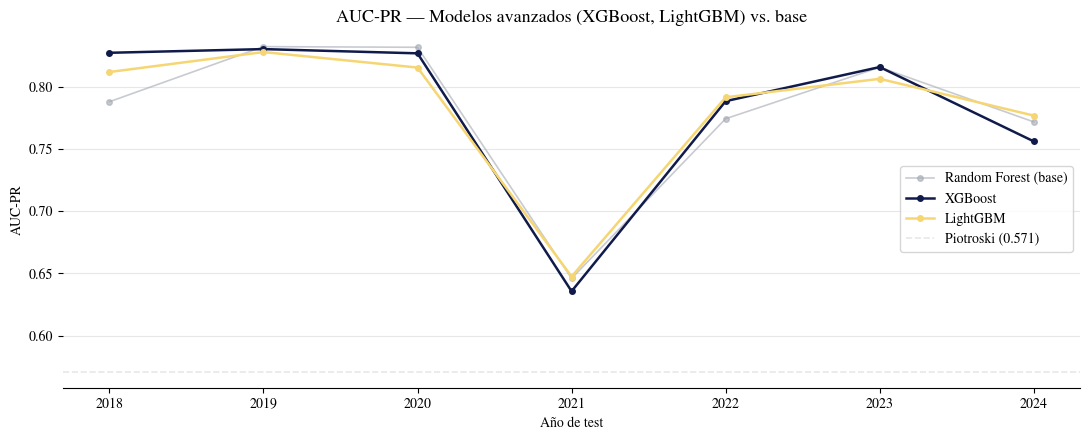

In [6]:
modelos_avanzados = {
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   XGBClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05,
            min_child_weight=10, random_state=42,
            eval_metric="aucpr", verbosity=0))
    ]),
    "LightGBM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   LGBMClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05,
            min_child_samples=10, random_state=42, verbose=-1))
    ]),
}

resultados_avanzados = {nombre: [] for nombre in modelos_avanzados}

for i, (ano_test, train, test) in enumerate(folds):
    for nombre, pipeline in modelos_avanzados.items():
        pipeline.fit(train[features].values, train["Y"].values)
        y_prob = pipeline.predict_proba(test[features].values)[:, 1]
        auc_pr = average_precision_score(test["Y"].values, y_prob)
        resultados_avanzados[nombre].append({
            "ano_test": ano_test, "auc_pr": auc_pr,
            "y_test": test["Y"].values, "y_prob": y_prob
        })
    print(f"Fold {i+1}/7 — {ano_test} ✓")

for nombre, folds_res in resultados_avanzados.items():
    vals = [f["auc_pr"] for f in folds_res]
    print(f"{nombre:<20} media={np.mean(vals):.3f}  std={np.std(vals):.3f}")

# --- Gráfico: comparación modelos avanzados vs. base ---
fig, ax = plt.subplots(figsize=(11, 4.5))
estilo_ax(ax, "vertical")

ax.plot(anos_test, [f["auc_pr"] for f in resultados["Random Forest"]],
        marker="o", markersize=4, linewidth=1.2, color=tech_colors[2],
        alpha=0.6, label="Random Forest (base)")
ax.plot(anos_test, [f["auc_pr"] for f in resultados_avanzados["XGBoost"]],
        marker="o", markersize=4, linewidth=1.8, color=tech_colors[0], label="XGBoost")
ax.plot(anos_test, [f["auc_pr"] for f in resultados_avanzados["LightGBM"]],
        marker="o", markersize=4, linewidth=1.8, color=tech_colors[5], label="LightGBM")

ax.axhline(auc_piotroski, color=tech_colors[3], linewidth=1.2,
           linestyle="--", label=f"Piotroski ({auc_piotroski:.3f})")
ax.set_title("AUC-PR — Modelos avanzados (XGBoost, LightGBM) vs. base",
             fontfamily=FUENTE, fontsize=13)
ax.set_xlabel("Año de test", fontfamily=FUENTE)
ax.set_ylabel("AUC-PR", fontfamily=FUENTE)
ax.set_xticks(anos_test)
ax.legend(prop={"family": FUENTE}, fontsize=9)
plt.tight_layout()
plt.show()

HITO CUADERNO 3 — Parte 4: Modelos avanzados (XGBoost y LightGBM)
==================================================================
Fecha: 10/08/2026
Notebook: 03_modelado_tech.ipynb

Qué se hizo:
- Se entrenaron XGBoost y LightGBM con parámetros equivalentes a los
  usados en el modelo general, sobre los mismos 7 folds del walk-forward.

Resultado:
                       AUC-PR medio   Std
XGBoost                    0.783     0.065
LightGBM                   0.782     0.057
Random Forest (base)       0.780     0.064

Mejora marginal pero consistente sobre Random Forest. La caída del
fold 2021 se replica en ambos modelos avanzados, confirmando que es
un efecto propio del periodo (alta volatilidad especulativa del sector
tecnológico) y no una debilidad de una arquitectura específica.

Importancia:
XGBoost y LightGBM ofrecen implementaciones más eficientes de boosting
que Gradient Boosting estándar, manteniendo (y mejorando levemente) el
poder predictivo, y sientan la base para incorporar variables
temporales de momentum en el siguiente paso.

# Parte 5 — Features temporales (momentum y rezagos)

Features base:          49
Features nuevas (OK):   16
Features totales:       65

Features descartadas por baja cobertura (<50%):
['margen_bruto_cambio', 'ingresos_cambio', 'margen_bruto_cambio_pct', 'ingresos_cambio_pct']
Fold 1/7 — 2018 ✓
Fold 2/7 — 2019 ✓
Fold 3/7 — 2020 ✓
Fold 4/7 — 2021 ✓
Fold 5/7 — 2022 ✓
Fold 6/7 — 2023 ✓
Fold 7/7 — 2024 ✓
RF + momentum             media=0.776  std=0.062
LightGBM + momentum       media=0.784  std=0.061


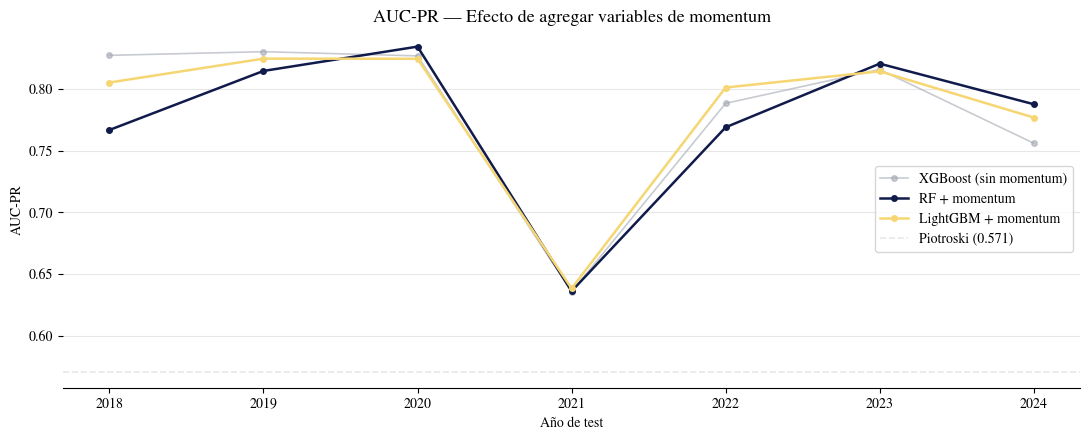

In [7]:
df = df.sort_values(["ticker", "end"])

vars_momentum = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate",
                 "margen_bruto", "ingresos"]
vars_rezago   = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate"]

for var in vars_momentum:
    df[f"{var}_cambio"]     = df.groupby("ticker", observed=True)[var].diff()
    df[f"{var}_cambio_pct"] = df.groupby("ticker", observed=True)[var].pct_change()

for var in vars_rezago:
    df[f"{var}_lag2"] = df.groupby("ticker", observed=True)[var].shift(2)
    df[f"{var}_lag4"] = df.groupby("ticker", observed=True)[var].shift(4)

todas_nuevas = ([f"{v}_cambio" for v in vars_momentum] +
                [f"{v}_cambio_pct" for v in vars_momentum] +
                [f"{v}_lag{l}" for v in vars_rezago for l in [2, 4]])

df[todas_nuevas] = df[todas_nuevas].replace([np.inf, -np.inf], np.nan)

# Conservar solo las con cobertura > 50%
features_nuevas_ok = [f for f in todas_nuevas if df[f].notna().mean() > 0.50]
features_con_momentum = features + features_nuevas_ok

print(f"Features base:          {len(features)}")
print(f"Features nuevas (OK):   {len(features_nuevas_ok)}")
print(f"Features totales:       {len(features_con_momentum)}")
print(f"\nFeatures descartadas por baja cobertura (<50%):")
print([f for f in todas_nuevas if f not in features_nuevas_ok])

# Regenerar folds con el dataset actualizado (incluye columnas nuevas)
folds_momentum = []
for ano_test in range(2018, 2025):
    train = df[df["ano"] < ano_test].copy()
    test  = df[df["ano"] == ano_test].copy()
    folds_momentum.append((ano_test, train, test))

modelos_momentum = {
    "RF + momentum": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(
            n_estimators=200, max_depth=None, min_samples_leaf=10,
            random_state=42, n_jobs=-1))
    ]),
    "LightGBM + momentum": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   LGBMClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05,
            min_child_samples=10, random_state=42, verbose=-1))
    ]),
}

resultados_momentum = {nombre: [] for nombre in modelos_momentum}

for i, (ano_test, train, test) in enumerate(folds_momentum):
    for nombre, pipeline in modelos_momentum.items():
        pipeline.fit(train[features_con_momentum].values, train["Y"].values)
        y_prob = pipeline.predict_proba(test[features_con_momentum].values)[:, 1]
        auc_pr = average_precision_score(test["Y"].values, y_prob)
        resultados_momentum[nombre].append({
            "ano_test": ano_test, "auc_pr": auc_pr,
            "y_test": test["Y"].values, "y_prob": y_prob
        })
    print(f"Fold {i+1}/7 — {ano_test} ✓")

for nombre, folds_res in resultados_momentum.items():
    vals = [f["auc_pr"] for f in folds_res]
    print(f"{nombre:<25} media={np.mean(vals):.3f}  std={np.std(vals):.3f}")

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(11, 4.5))
estilo_ax(ax, "vertical")

ax.plot(anos_test, [f["auc_pr"] for f in resultados_avanzados["XGBoost"]],
        marker="o", markersize=4, linewidth=1.2, color=tech_colors[2],
        alpha=0.6, label="XGBoost (sin momentum)")
ax.plot(anos_test, [f["auc_pr"] for f in resultados_momentum["RF + momentum"]],
        marker="o", markersize=4, linewidth=1.8, color=tech_colors[0], label="RF + momentum")
ax.plot(anos_test, [f["auc_pr"] for f in resultados_momentum["LightGBM + momentum"]],
        marker="o", markersize=4, linewidth=1.8, color=tech_colors[5], label="LightGBM + momentum")

ax.axhline(auc_piotroski, color=tech_colors[3], linewidth=1.2,
           linestyle="--", label=f"Piotroski ({auc_piotroski:.3f})")
ax.set_title("AUC-PR — Efecto de agregar variables de momentum",
             fontfamily=FUENTE, fontsize=13)
ax.set_xlabel("Año de test", fontfamily=FUENTE)
ax.set_ylabel("AUC-PR", fontfamily=FUENTE)
ax.set_xticks(anos_test)
ax.legend(prop={"family": FUENTE}, fontsize=9)
plt.tight_layout()
plt.show()

HITO CUADERNO 3 — Parte 5: Features temporales (momentum y rezagos)
==================================================================
Fecha: 10/08/2026
Notebook: 03_modelado_tech.ipynb

Qué se hizo:
- Se construyeron 20 variables temporales candidatas (cambios trimestrales
  absolutos y porcentuales sobre 6 variables, y rezagos de 2 y 4
  trimestres sobre 4 variables), conservando solo las que superaron el
  50% de cobertura de datos.

Resultado:
- 16 de 20 variables temporales candidatas superaron el umbral de
  cobertura (65 features totales: 49 base + 16 temporales).
- Descartadas por baja cobertura: margen_bruto_cambio, ingresos_cambio,
  margen_bruto_cambio_pct, ingresos_cambio_pct.
- RF + momentum: AUC-PR 0.776 (std 0.062) -- prácticamente sin cambio
  frente a RF sin momentum (0.780).
- LightGBM + momentum: AUC-PR 0.784 (std 0.061) -- mejora leve frente
  a LightGBM sin momentum (0.782) y frente a XGBoost (0.783).

Importancia:
Las variables de momentum aportan una mejora marginal en el universo
tecnológico, a diferencia del modelo general donde el momentum tuvo
un rol más determinante. Esto es consistente con la hipótesis de fondo
del ajuste sectorial: en tecnología, el estado financiero puntual
(liquidez, rentabilidad acumulada) pesa más que la tendencia reciente,
posiblemente porque los ciclos de inversión son más largos y una
tendencia de pocos trimestres es menos informativa.

# Ajustes a los Features Temporales:

En el desarrollo de las varibles de momentum se determino que no aportan un peso significativo al RF y al LightGBM, por tanto se determina implementar una combinacion de la ampliacion de variables de momentum "clasico" de liquidez (ratio_corriente, capital_trabajo, pasivos_corrientes), no solo las 6 originales, y agregar una tendencia de 4 trimestres (comparar el valor actual contra el promedio móvil de los últimos 4 trimestres) — esto captura mejor una tendencia sostenida, más apropiado para ciclos largos de tecnología.

## 5b. Mejora de las variables de momentum

El momentum "clásico" (cambios trimestre a trimestre) aportó una mejora
marginal (RF: 0.776, LightGBM: 0.784) frente a los modelos sin momentum
(0.780 y 0.782 respectivamente) — una diferencia casi nula.

Features nuevas v2 (OK):   29
Features totales v2:       78

Features nuevas incluidas:
['fcf_operativo_cambio_v2', 'utilidad_neta_cambio_v2', 'caja_cambio_v2', 'burn_rate_cambio_v2', 'ratio_corriente_cambio_v2', 'capital_trabajo_cambio_v2', 'pasivos_corrientes_cambio_v2', 'fcf_operativo_cambio_pct_v2', 'utilidad_neta_cambio_pct_v2', 'caja_cambio_pct_v2', 'burn_rate_cambio_pct_v2', 'ratio_corriente_cambio_pct_v2', 'capital_trabajo_cambio_pct_v2', 'pasivos_corrientes_cambio_pct_v2', 'fcf_operativo_lag2_v2', 'fcf_operativo_lag4_v2', 'utilidad_neta_lag2_v2', 'utilidad_neta_lag4_v2', 'caja_lag2_v2', 'caja_lag4_v2', 'burn_rate_lag2_v2', 'burn_rate_lag4_v2', 'ratio_corriente_lag2_v2', 'ratio_corriente_lag4_v2', 'ratio_corriente_tendencia4t', 'capital_trabajo_tendencia4t', 'caja_tendencia4t', 'burn_rate_tendencia4t', 'pasivos_corrientes_tendencia4t']
Fold 1/7 — 2018 ✓
Fold 2/7 — 2019 ✓
Fold 3/7 — 2020 ✓
Fold 4/7 — 2021 ✓
Fold 5/7 — 2022 ✓
Fold 6/7 — 2023 ✓
Fold 7/7 — 2024 ✓

Comparación      

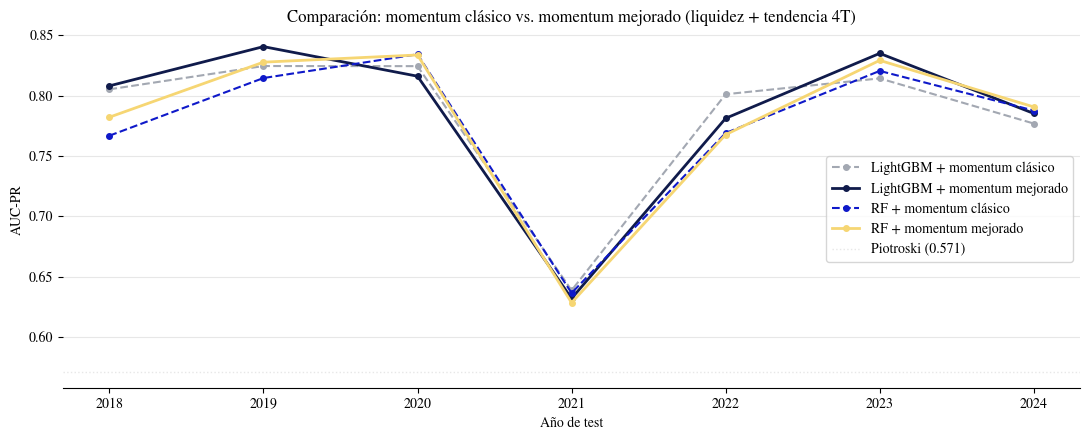

In [8]:
# --- Momentum mejorado: liquidez + tendencia de 4 trimestres ---
vars_momentum_v2 = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate",
                    "margen_bruto", "ingresos",
                    "ratio_corriente", "capital_trabajo", "pasivos_corrientes"]
vars_rezago_v2   = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate",
                    "ratio_corriente"]
vars_tendencia    = ["ratio_corriente", "capital_trabajo", "caja", "burn_rate", "pasivos_corrientes"]

for var in vars_momentum_v2:
    df[f"{var}_cambio_v2"]     = df.groupby("ticker", observed=True)[var].diff()
    df[f"{var}_cambio_pct_v2"] = df.groupby("ticker", observed=True)[var].pct_change()

for var in vars_rezago_v2:
    df[f"{var}_lag2_v2"] = df.groupby("ticker", observed=True)[var].shift(2)
    df[f"{var}_lag4_v2"] = df.groupby("ticker", observed=True)[var].shift(4)

for var in vars_tendencia:
    promedio_movil_4t = (
        df.groupby("ticker", observed=True)[var]
        .transform(lambda x: x.shift(1).rolling(window=4, min_periods=3).mean())
    )
    df[f"{var}_tendencia4t"] = (df[var] - promedio_movil_4t) / promedio_movil_4t.abs()

todas_nuevas_v2 = ([f"{v}_cambio_v2" for v in vars_momentum_v2] +
                   [f"{v}_cambio_pct_v2" for v in vars_momentum_v2] +
                   [f"{v}_lag{l}_v2" for v in vars_rezago_v2 for l in [2, 4]] +
                   [f"{v}_tendencia4t" for v in vars_tendencia])

df[todas_nuevas_v2] = df[todas_nuevas_v2].replace([np.inf, -np.inf], np.nan)

features_nuevas_v2_ok = [f for f in todas_nuevas_v2 if df[f].notna().mean() > 0.50]
features_con_momentum_v2 = features + features_nuevas_v2_ok

print(f"Features nuevas v2 (OK):   {len(features_nuevas_v2_ok)}")
print(f"Features totales v2:       {len(features_con_momentum_v2)}")
print(f"\nFeatures nuevas incluidas:")
print(features_nuevas_v2_ok)

# Regenerar folds con las columnas nuevas
folds_momentum_v2 = []
for ano_test in range(2018, 2025):
    train = df[df["ano"] < ano_test].copy()
    test  = df[df["ano"] == ano_test].copy()
    folds_momentum_v2.append((ano_test, train, test))

modelos_momentum_v2 = {
    "RF + momentum v2": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(
            n_estimators=200, max_depth=None, min_samples_leaf=10,
            random_state=42, n_jobs=-1))
    ]),
    "LightGBM + momentum v2": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   LGBMClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05,
            min_child_samples=10, random_state=42, verbose=-1))
    ]),
}

resultados_momentum_v2 = {nombre: [] for nombre in modelos_momentum_v2}

for i, (ano_test, train, test) in enumerate(folds_momentum_v2):
    for nombre, pipeline in modelos_momentum_v2.items():
        pipeline.fit(train[features_con_momentum_v2].values, train["Y"].values)
        y_prob = pipeline.predict_proba(test[features_con_momentum_v2].values)[:, 1]
        auc_pr = average_precision_score(test["Y"].values, y_prob)
        resultados_momentum_v2[nombre].append({
            "ano_test": ano_test, "auc_pr": auc_pr,
            "y_test": test["Y"].values, "y_prob": y_prob
        })
    print(f"Fold {i+1}/7 — {ano_test} ✓")

print(f"\n{'Comparación':<28} {'Media':>8} {'Std':>8}")
print("-" * 46)
for nombre, folds_res in resultados_momentum.items():
    vals = [f["auc_pr"] for f in folds_res]
    print(f"{nombre:<28} {np.mean(vals):>8.3f} {np.std(vals):>8.3f}")
for nombre, folds_res in resultados_momentum_v2.items():
    vals = [f["auc_pr"] for f in folds_res]
    print(f"{nombre:<28} {np.mean(vals):>8.3f} {np.std(vals):>8.3f}")

# --- Gráfico comparativo: momentum clásico vs. mejorado ---
fig, ax = plt.subplots(figsize=(11, 4.5))
estilo_ax(ax, "vertical")

ax.plot(anos_test, [f["auc_pr"] for f in resultados_momentum["LightGBM + momentum"]],
        marker="o", markersize=4, linewidth=1.5, color=tech_colors[2],
        linestyle="--", label="LightGBM + momentum clásico")
ax.plot(anos_test, [f["auc_pr"] for f in resultados_momentum_v2["LightGBM + momentum v2"]],
        marker="o", markersize=4, linewidth=2, color=tech_colors[0],
        label="LightGBM + momentum mejorado")
ax.plot(anos_test, [f["auc_pr"] for f in resultados_momentum["RF + momentum"]],
        marker="o", markersize=4, linewidth=1.5, color=tech_colors[4],
        linestyle="--", label="RF + momentum clásico")
ax.plot(anos_test, [f["auc_pr"] for f in resultados_momentum_v2["RF + momentum v2"]],
        marker="o", markersize=4, linewidth=2, color=tech_colors[5],
        label="RF + momentum mejorado")

ax.axhline(auc_piotroski, color=tech_colors[3], linewidth=1.0,
           linestyle=":", label=f"Piotroski ({auc_piotroski:.3f})")
ax.set_title("Comparación: momentum clásico vs. momentum mejorado (liquidez + tendencia 4T)",
             fontfamily=FUENTE, fontsize=12)
ax.set_xlabel("Año de test", fontfamily=FUENTE)
ax.set_ylabel("AUC-PR", fontfamily=FUENTE)
ax.set_xticks(anos_test)
ax.legend(prop={"family": FUENTE}, fontsize=8)
plt.tight_layout()
plt.show()


# Conclusion 5b:

Las mejoras propuestas a las variables de momentum clásico no arrojaron una
diferencia estadísticamente significativa (+0.004 en Random Forest, +0.001
en LightGBM), lo cual es consistente con encontrarse dentro del rango de
variación natural (ruido) observado entre folds del walk-forward (std ≈ 0.06).
Por criterio de parsimonia —preferir el modelo más simple cuando el desempeño
es equivalente—, se decide continuar con las variables de momentum clásico
(65 variables) para el ensemble final, en lugar de la versión ampliada de 78
variables.

# Parte 8 — Ensemble (modelo final)

Fold 1/7 — 2018 ✓
Fold 2/7 — 2019 ✓
Fold 3/7 — 2020 ✓
Fold 4/7 — 2021 ✓
Fold 5/7 — 2022 ✓
Fold 6/7 — 2023 ✓
Fold 7/7 — 2024 ✓

Ensemble RF + LightGBM: media=0.783  std=0.060


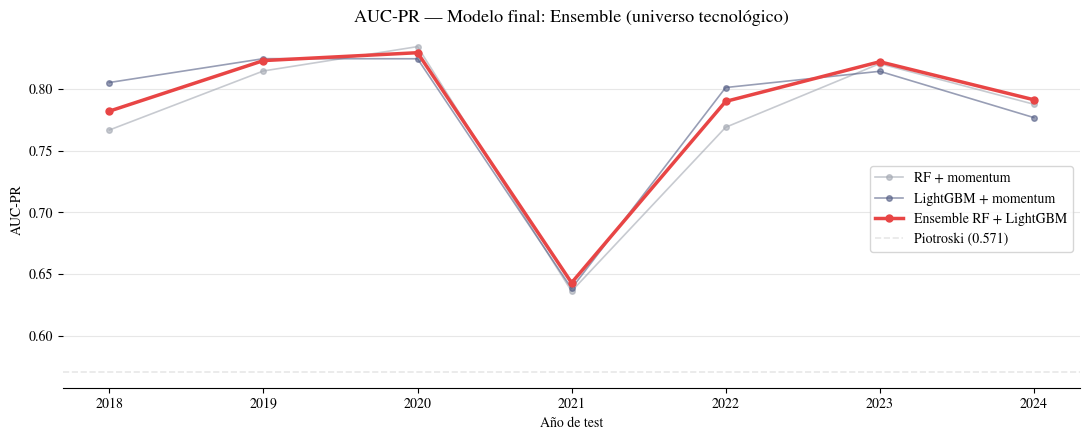

In [9]:
rf_ens = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=10,
        random_state=42, n_jobs=-1))
])
lgbm_ens = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.05,
        min_child_samples=10, random_state=42, verbose=-1))
])

resultados_ensemble = []

for i, (ano_test, train, test) in enumerate(folds_momentum):
    rf_ens.fit(train[features_con_momentum].values, train["Y"].values)
    lgbm_ens.fit(train[features_con_momentum].values, train["Y"].values)

    prob_rf   = rf_ens.predict_proba(test[features_con_momentum].values)[:, 1]
    prob_lgbm = lgbm_ens.predict_proba(test[features_con_momentum].values)[:, 1]
    prob_ens  = (prob_rf + prob_lgbm) / 2

    auc_pr = average_precision_score(test["Y"].values, prob_ens)
    resultados_ensemble.append({
        "ano_test": ano_test, "auc_pr": auc_pr,
        "y_test": test["Y"].values, "y_prob": prob_ens
    })
    print(f"Fold {i+1}/7 — {ano_test} ✓")

vals_ens = [f["auc_pr"] for f in resultados_ensemble]
print(f"\nEnsemble RF + LightGBM: media={np.mean(vals_ens):.3f}  std={np.std(vals_ens):.3f}")

# --- Gráfico: modelo final ---
fig, ax = plt.subplots(figsize=(11, 4.5))
estilo_ax(ax, "vertical")

ax.plot(anos_test, [f["auc_pr"] for f in resultados_momentum["RF + momentum"]],
        marker="o", markersize=4, linewidth=1.2, color=tech_colors[2],
        alpha=0.6, label="RF + momentum")
ax.plot(anos_test, [f["auc_pr"] for f in resultados_momentum["LightGBM + momentum"]],
        marker="o", markersize=4, linewidth=1.2, color=tech_colors[1],
        alpha=0.6, label="LightGBM + momentum")
ax.plot(anos_test, vals_ens,
        marker="o", markersize=5, linewidth=2.5, color="#E84545",
        label="Ensemble RF + LightGBM", zorder=5)

ax.axhline(auc_piotroski, color=tech_colors[3], linewidth=1.2,
           linestyle="--", label=f"Piotroski ({auc_piotroski:.3f})")
ax.set_title("AUC-PR — Modelo final: Ensemble (universo tecnológico)",
             fontfamily=FUENTE, fontsize=13)
ax.set_xlabel("Año de test", fontfamily=FUENTE)
ax.set_ylabel("AUC-PR", fontfamily=FUENTE)
ax.set_xticks(anos_test)
ax.legend(prop={"family": FUENTE}, fontsize=9)
plt.tight_layout()
plt.show()

HITO — CUADERNO 3. Parte 8: Modelo final
==================================================================
Fecha:14/08/2026
Notebook: 03_modelado_tech.ipynb

Qué se hizo:
- Se combinó Random Forest y LightGBM (ambos con variables de momentum
  clásico, 65 features) mediante promedio de probabilidades, sobre los
  7 folds del walk-forward ajustado (2018-2024).

Resultado:
- Ensemble RF + LightGBM: AUC-PR = 0.783 (std = 0.060)
- Mejora de 37% sobre Piotroski (0.571) y de 38% sobre el baseline
  aleatorio (0.567)
- Comparado con el modelo general (AUC-PR 0.762, std 0.067): el modelo
  tecnológico logra un desempeño ligeramente superior y con menor
  variabilidad entre folds, a pesar de contar con muchas menos
  observaciones (3.390 vs. 27.382).

Importancia:
Este es el modelo predictivo definitivo para el universo tecnológico,
y responde directamente a la recomendación del asesor de tesis: acotar
el modelo por sector no solo resuelve la inconsistencia de horizontes
temporales entre industrias, sino que además produce un modelo más
preciso y más estable que el modelo multisectorial original.

# Se guarda el modelo final y las predicciones

In [10]:
import pickle

# Reentrenar ensemble con todos los datos disponibles (hasta 2024)
X_todo = df[features_con_momentum].values
y_todo = df["Y"].values

rf_final_completo = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=10,
        random_state=42, n_jobs=-1))
])
lgbm_final_completo = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.05,
        min_child_samples=10, random_state=42, verbose=-1))
])

rf_final_completo.fit(X_todo, y_todo)
lgbm_final_completo.fit(X_todo, y_todo)

Path("../salidas").mkdir(exist_ok=True)
with open("../salidas/modelo_rf_final_tech.pkl", "wb") as f:
    pickle.dump(rf_final_completo, f)
with open("../salidas/modelo_lgbm_final_tech.pkl", "wb") as f:
    pickle.dump(lgbm_final_completo, f)

pd.Series(features_con_momentum).to_csv("../salidas/features_modelo_tech.csv", index=False)

df_wf = pd.DataFrame([
    {"modelo": "Ensemble RF + LightGBM",
     "ano_test": f["ano_test"],
     "auc_pr": f["auc_pr"]}
    for f in resultados_ensemble
])
df_wf.to_csv("../salidas/resultados_walkforward_tech.csv", index=False)

print("Modelos y resultados guardados en salidas/")
print(f"\nFeatures del modelo final: {len(features_con_momentum)}")
print(f"AUC-PR promedio final:     {np.mean(vals_ens):.3f}")
print(f"Mejora vs aleatorio:       +{(np.mean(vals_ens) - auc_aleatorio)/auc_aleatorio*100:.0f}%")
print(f"Mejora vs Piotroski:       +{(np.mean(vals_ens) - auc_piotroski)/auc_piotroski*100:.0f}%")

Modelos y resultados guardados en salidas/

Features del modelo final: 65
AUC-PR promedio final:     0.783
Mejora vs aleatorio:       +38%
Mejora vs Piotroski:       +37%


HITO — CUADERNO 3, Parte 9: Guardado del modelo final y predicciones
==================================================================
Fecha: 14/08/2026
Notebook: 03_modelado_tech.ipynb

Qué se hizo:
- Se reentrenó el ensemble (Random Forest + LightGBM) con la totalidad
  de los datos disponibles (2008-2025), usando las variables de
  momentum clásico (65 features), para producir el modelo final listo
  para generar predicciones sobre cualquier observación.
- Se guardaron los modelos entrenados, la lista de features, y los
  resultados del walk-forward.

Resultado:
- Archivos generados en salidas/:
  - modelo_rf_final_tech.pkl
  - modelo_lgbm_final_tech.pkl
  - features_modelo_tech.csv (65 variables)
  - resultados_walkforward_tech.csv (AUC-PR por fold)

Importancia:
Con esto se cierra formalmente el Cuaderno 3. El modelo tecnológico
final queda guardado y listo para ser usado en el análisis de
explicabilidad (SHAP, Cuaderno 4), la construcción del portafolio
recomendado (Cuaderno 5), y el análisis corporativo (Cuaderno 6).